# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterKmeansModule as ck
import Modules.ClusterDBSCANModule as cd
import Modules.ClusterHDBSCANModule as ch
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
featuresNotConsidered = ["died", "died_in_stay", "died_after", "COVID", "subject_id", "hadm_id"]

## Models

In [6]:
kmeans = ck.KmeansClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered, scaler= "standard")
# kmeans.kMeans(k=2)
# kmeans.getMetrics()

In [ ]:
best_param, best_reduction = (
    {'eps': 1.1438645999255257, 'min_samples': 43},
    {"method": "AE", "dimensions": 10},
)

dbscan = cd.DBSCANClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered, scaler= "standard")
dbscan.clustering(eps=best_param["eps"], min_samples=best_param["min_samples"], dimensionality_reduction=best_reduction)
dbscan.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.397,
 'dbcv': 0.814008054669527,
 'dsi': np.float64(0.18),
 'disco': np.float64(0.40187727063132533)}

In [ ]:
best_param = {'min_cluster_size': 2, 'min_samples': 4}

hdbscan = ch.HDBSCANClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered, scaler= "standard")
hdbscan.clustering(min_cluster_size=best_param['min_cluster_size'], min_samples=best_param['min_samples'])
hdbscan.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.44,
 'dbcv': 0.8399399315640403,
 'dsi': np.float64(0.368),
 'disco': np.float64(0.42906275624009127)}

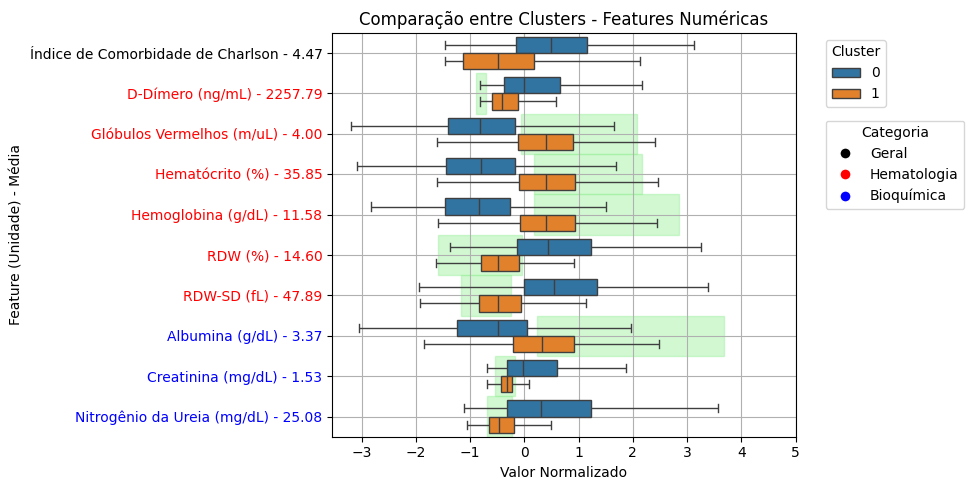

In [ ]:
top_k =  kmeans.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=10,
    selectedClusters=[0,1],
    figsize=(10, 5),
    byVariance=True,
)

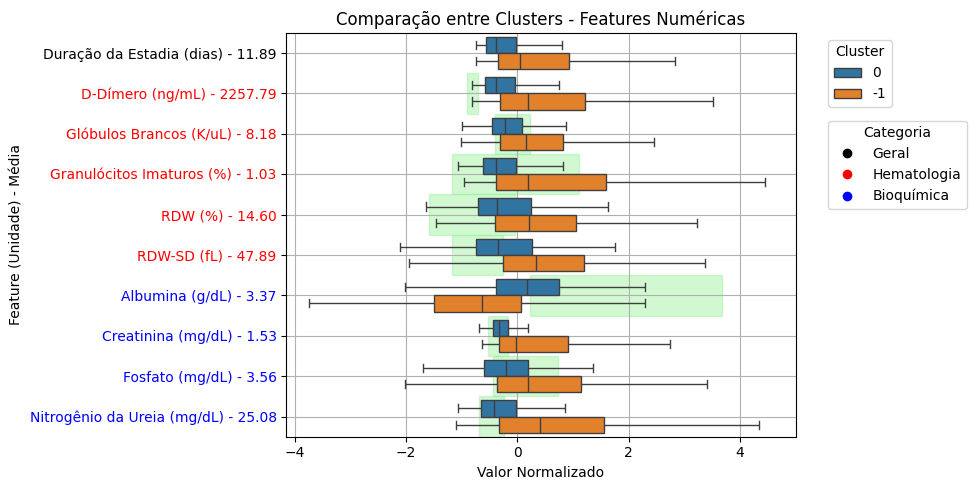

In [ ]:
top_d =  dbscan.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=10,
    selectedClusters=[0,-1],
    figsize=(10, 5),
    byVariance=True,
)

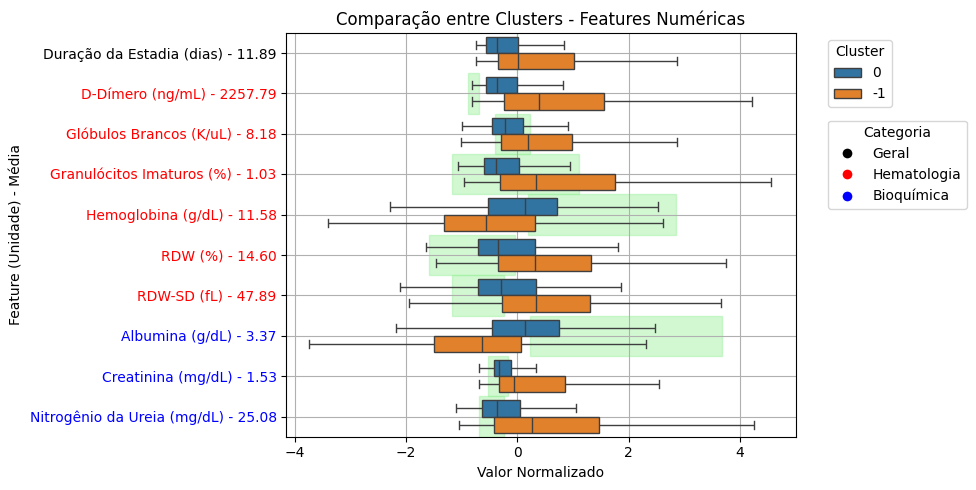

In [ ]:
top_h = hdbscan.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=10,
    selectedClusters=[0,-1],
    figsize=(10, 5),
    byVariance=True,
)

In [ ]:
def main(top_k, top_d, top_h, top):

    k = set(map(lambda x: x[0], top_k[:top]))
    d = set(map(lambda x: x[0], top_d[:top]))
    h = set(map(lambda x: x[0], top_h[:top]))

    intersection = list(k.intersection(d).intersection(h))

    # from pprint import pprint
    # pprint(intersection)
    print("Count:", len(intersection))  

    top_k = kmeans.showClusterCompareNumerical(
        scaled="proportional",
        topFeatures=-1,
        max_features=-1,
        selectedClusters=[0, 1],
        figsize=(10, 5),
        byVariance=True,
        selected_features_list=intersection,
        savepath=IMAGES_SAVE_PATH + "kmeans-all-numerical",
    )

    top_d = dbscan.showClusterCompareNumerical(
        scaled="proportional",
        topFeatures=-1,
        max_features=-1,
        selectedClusters=[-1, 0],
        figsize=(10, 5),
        byVariance=True,
        selected_features_list=intersection,
        savepath=IMAGES_SAVE_PATH + "dbscan-ae-numerical",
    )

    top_h = hdbscan.showClusterCompareNumerical(
        scaled="proportional",
        topFeatures=-1,
        max_features=-1,
        selectedClusters=[-1, 0],
        figsize=(10, 5),
        byVariance=True,
        selected_features_list=intersection,
        savepath=IMAGES_SAVE_PATH + "hdbscan-all-numerical",
    )

Count: 13


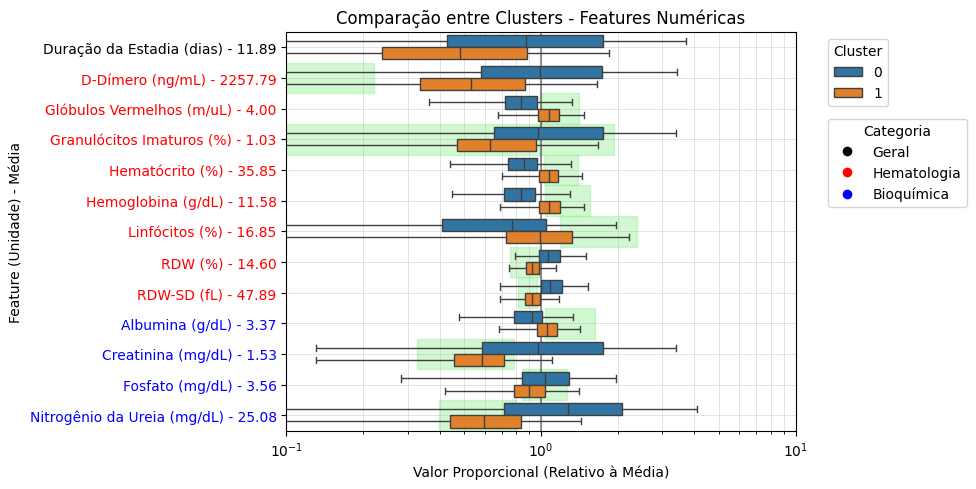

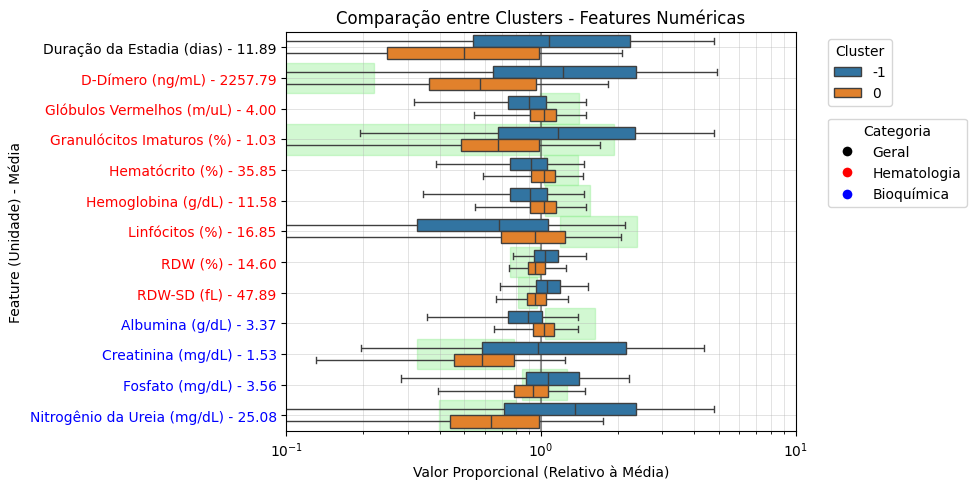

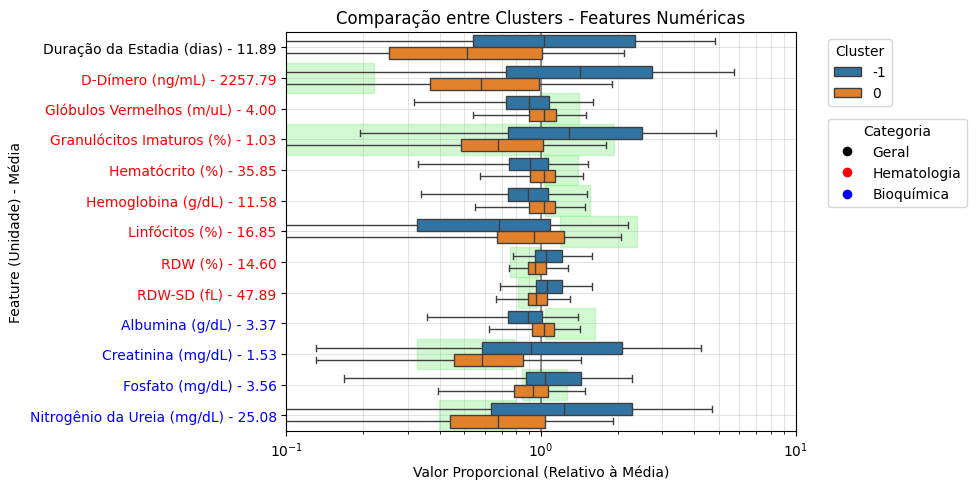

In [ ]:
top = 15

a = top_k.copy()
b = top_d.copy()
c = top_h.copy()

main(a, b, c, top)